In [ ]:
#importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping
import re
import pandas as pd
from textblob import TextBlob

The dataset used her is taken from Kaggle.com. It has mixed tweets based on the data collected.

In [ ]:
dataset_path = "/content/twitter_Kaggle.csv"  #adding the csv data file 'twitter_kaggle'
data = pd.read_csv(dataset_path)

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB
None


Data Preprocessing : Includes cleaning the data and assigning a basic sentiment to texts for performing analysis.

In [ ]:
#defining a function to clean the data and make it readable for the ML model to interpret
def preprocess_text(tweet):
    tweet = tweet.lower()
    tweet = re.sub("@[\w]*", "", tweet) #removes username handles
    tweet = re.sub("http\S+", "", tweet) # removed web link
    tweet = re.sub("[^a-zA-Z#]", " ", tweet) #removing specific characters and hashtags
    tweet = re.sub("rt", "", tweet)
    tweet = re.sub("\s+", " ", tweet)

    return tweet

#defining a function to assign basic sentiment detected using lexicon method.
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'







In [ ]:
#Pre-processed data needs to resaved in a csv file.
data["preprocessed_text"] = data["tweet"].apply(preprocess_text)
data['sentiment'] = data['preprocessed_text'].apply(get_sentiment)

data.to_csv("New_kaggle_dataset.csv", index=False)

print("Preprocessed dataset saved as 'New_kaggle_dataset.csv'")

Preprocessed dataset saved as 'New_kaggle_dataset.csv'


In [ ]:
dataset_path_new = "/content/New_kaggle_dataset.csv"  #reading the new dataset
new_data = pd.read_csv(dataset_path_new)

**Model Training and Evaluation using confusion matrix**

1. Split the Data into Features and Labels (data and it's respective sentiment recorded after pre-processing the data)
2. Use train_test_split to create training and testing subsets.
3. Defining the model (CNN and LSTM)
4. Training the model
5. Evaluating the model using confusion matrix and classification report




Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.5009 - loss: 1.0192 - val_accuracy: 0.6833 - val_loss: 0.7167
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.7551 - loss: 0.6107 - val_accuracy: 0.7633 - val_loss: 0.5558
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 0.9419 - loss: 0.2063 - val_accuracy: 0.8000 - val_loss: 0.5561
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 0.9914 - loss: 0.0555 - val_accuracy: 0.7967 - val_loss: 0.7169
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.9967 - loss: 0.0159 - val_accuracy: 0.7950 - val_loss: 0.7577
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.9974 - loss: 0.0143 - val_accuracy: 0.7950 - val_loss: 0.9648
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.9969 - loss: 0.0160 - val_accuracy: 0.7967 - val_loss: 0.9085
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.9989 - loss: 0.0069 - val_accuracy: 0.7933 

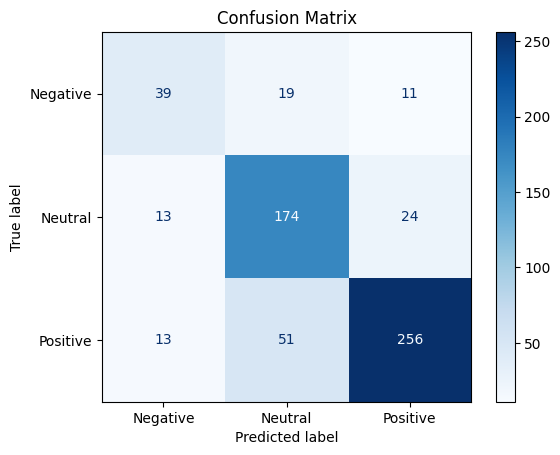

              precision    recall  f1-score   support

    Negative       0.60      0.57      0.58        69
     Neutral       0.71      0.82      0.76       211
    Positive       0.88      0.80      0.84       320

    accuracy                           0.78       600
   macro avg       0.73      0.73      0.73       600
weighted avg       0.79      0.78      0.78       600



In [ ]:
# setting parameters for the model like vocabulary size, max sequence length and embedding dimensions
max_words = 10000
max_len = 100
embedding_dim = 100

def preprocess_data(new_data, max_words, max_len):
    tokenizer = Tokenizer(num_words=max_words)
    tokenizer.fit_on_texts(data['preprocessed_text'])
    sequences = tokenizer.texts_to_sequences(data['preprocessed_text'])
    padded_sequences = pad_sequences(sequences, maxlen=max_len)
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(data['sentiment'])
    return padded_sequences, labels, tokenizer.word_index, label_encoder

X, y, word_index, label_encoder = preprocess_data(data, max_words, max_len)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  CNN-LSTM model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(units=128, return_sequences=False),
    Dense(units=64, activation='relu'),
    Dropout(rate=0.5),
    Dense(units=len(label_encoder.classes_), activation='softmax')  # Adjust output units
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)


y_pred = np.argmax(model.predict(X_test), axis=1) #evaluating the model

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

**Data Visualization**

1. **Line graph** : depicting training and validation loss for the model  
2. **ROC curve** for multiclass classification.
3. **Historgram:** depicting the prediction confidence score for each sentiment
4. **Histogram :** depicting the distribution of positive, negative and neutral sentiments
5. **Boxplot :** depicting outliers and confidence scores of the data
6. **Word clouds :** depicting the frequency of positive , negative and nuetral words and their usage in the text.

In [ ]:
#Visualization of the data !

import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


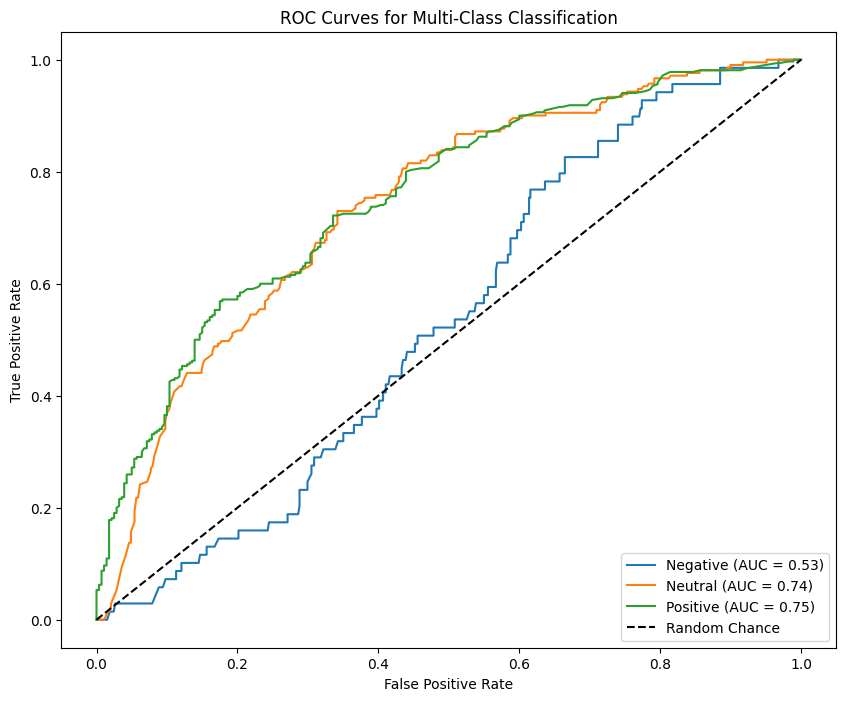

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the labels for ROC
y_test_binarized = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))
y_pred_proba = model.predict(X_test)

# Plot ROC curve for each class
#To evaluate the performance of the model for each class.

plt.figure(figsize=(10, 8))
for i, label in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curves for Multi-Class Classification')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


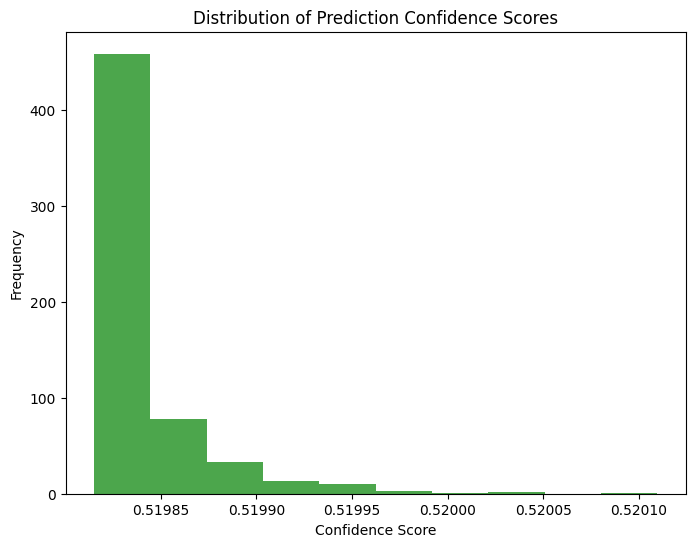

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.max(model.predict(X_test), axis=1), bins=10, color='green', alpha=0.7)
plt.title('Distribution of Prediction Confidence Scores')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.show()


<ipython-input-18-f34abd873f8c>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="coolwarm")


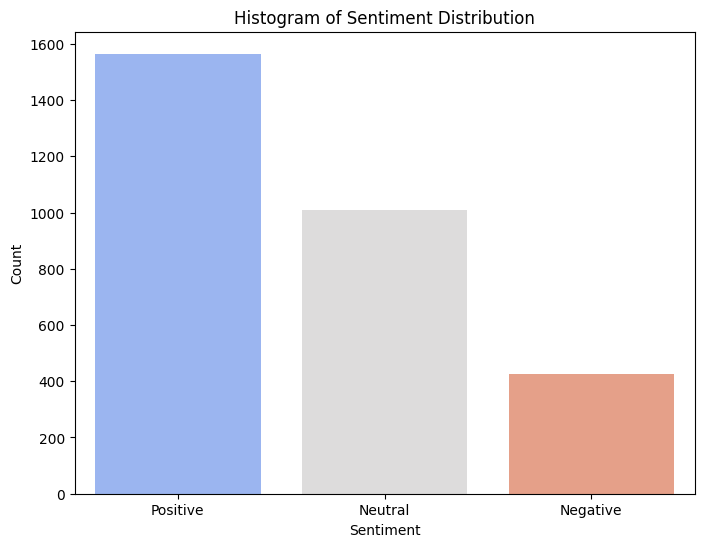

In [ ]:
import seaborn as sns

# Count the sentiment distribution
sentiment_counts = data['sentiment'].value_counts()

# Plot histogram
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="coolwarm")
plt.title('Histogram of Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


<ipython-input-19-532da08b94cc>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment', y='Confidence', data=data_test, palette="Set2")


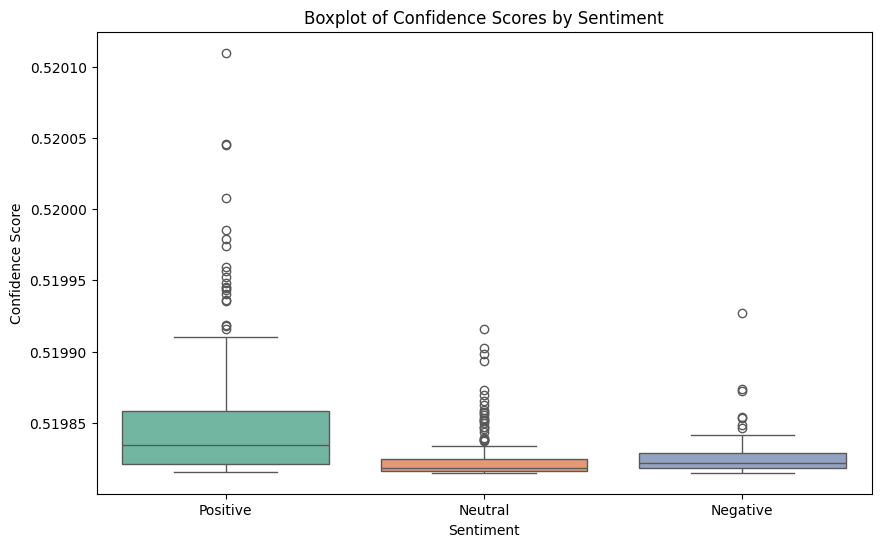

In [ ]:
# Add predicted confidence scores to the DataFrame
confidence_scores = np.max(model.predict(X_test), axis=1)
data_test = pd.DataFrame({'Sentiment': label_encoder.inverse_transform(y_test), 'Confidence': confidence_scores})

# Plot boxplot for confidence scores grouped by sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sentiment', y='Confidence', data=data_test, palette="Set2")
plt.title('Boxplot of Confidence Scores by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Confidence Score')
plt.show()


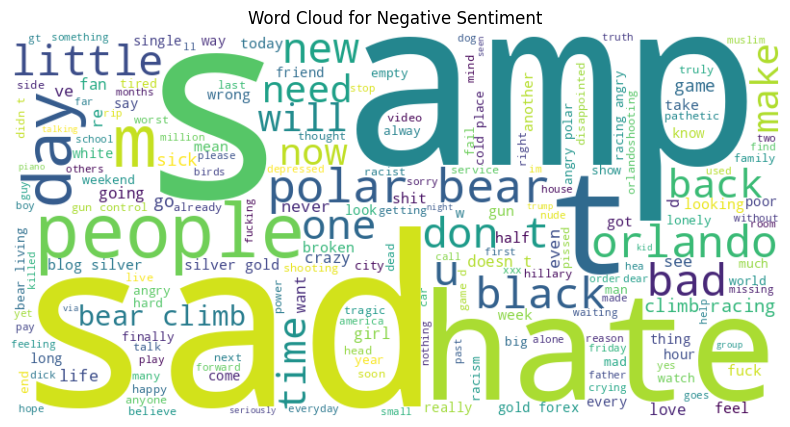

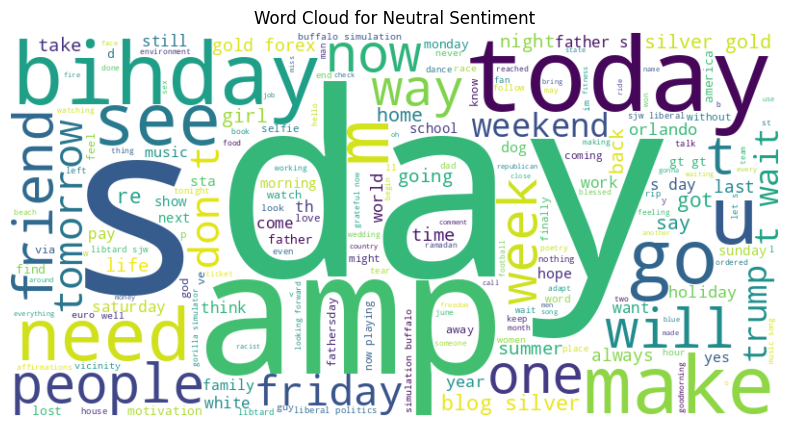

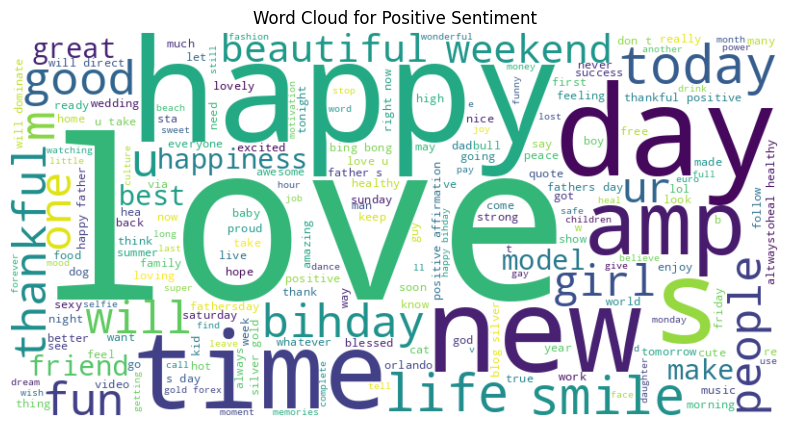

In [ ]:
from wordcloud import WordCloud

# Generate word clouds for each sentiment
for sentiment in label_encoder.classes_:
    sentiment_texts = data[data['sentiment'] == sentiment]['preprocessed_text']
    all_text = ' '.join(sentiment_texts)

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {sentiment} Sentiment')
    plt.show()
